In [1]:
import sys
import importlib
import numpy as np
import pandas as pd
import uproot
import matplotlib.pyplot as plt
import sys
sys.path.insert(0,"../")
import mplhep as hep
import pickle
import glob
import ROOT
import coffea
import awkward as ak
from coffea import processor
from coffea.nanoevents.methods import vector
import dask_awkward as dak
import hist

Welcome to JupyROOT 6.30/07


/cvmfs/cms.cern.ch/el9_amd64_gcc12/lcg/root/6.30.07-024df6516c17fd2edef848a927a788f1/lib/ROOT/_facade.py:154: FutureWarning: In version 2025.1.0 (target date: 2024-12-31 11:59:59-06:00), this will be an error.
To raise these warnings as errors (and get stack traces to find out where they're called), run
    import warnings
    warnings.filterwarnings("error", module="coffea.*")
after the first `import coffea` or use `@pytest.mark.filterwarnings("error:::coffea.*")` in pytest.
Issue: coffea.nanoevents.methods.vector will be removed and replaced with scikit-hep vector. Nanoevents schemas internal to coffea will be migrated. Otherwise please consider using that package!.
  return _orig_ihook(name, *args, **kwds)
/cvmfs/cms.cern.ch/el8_amd64_gcc12/external/py3-numpy/1.24.3-0831476b9e4ddf0b4b9eb1f4c971c0d1/lib/python3.9/site-packages/numpy/core/getlimits.py:518: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, w

In [2]:
sys.path.insert(0,"../python/HNL_Plotting_HelperFunctions")
import MuonSystemReader
import Produce_Cutflow_v2
import DNN_Helpers
import Processing_Helpers


In [3]:
HNL_2GeV_10ctau_path = "root://cmseos.fnal.gov//store/group/lpclonglived/amalbert/HNL_Tau_Search/analyzer_update_042926/HNL_tau_mN_2_ctau_1000/normalized/HNL_tau_mN_2_ctau_1000_109080pb_weighted.root"
signal_events  = MuonSystemReader.loadTree_nanoFactory(HNL_2GeV_10ctau_path)

HNL_2GeV_10ctau_path = "root://cmseos.fnal.gov//store/group/lpclonglived/amalbert/HNL_Tau_Search/analyzer_update_042926/HNL_e_mN_2_ctau_1000/normalized/HNL_e_mN_2_ctau_1000_109080pb_weighted.root"
signal_events_e  = MuonSystemReader.loadTree_nanoFactory(HNL_2GeV_10ctau_path)

HNL_2GeV_10ctau_path = "root://cmseos.fnal.gov//store/group/lpclonglived/amalbert/HNL_Tau_Search/analyzer_update_042926/HNL_mu_mN_2_ctau_1000/normalized/HNL_mu_mN_2_ctau_1000_109080pb_weighted.root"
signal_events_mu  = MuonSystemReader.loadTree_nanoFactory(HNL_2GeV_10ctau_path)


/uscms/home/amalbert/.local/lib/python3.9/site-packages/coffea/nanoevents/factory.py:317: RuntimeWarning: You have set steps_per_file to 4, this should only be used for a
                small number of inputs (e.g. for early-stage/exploratory analysis) since it does not
                inform dask of each chunk lengths at creation time, which can cause unexpected
                slowdowns at scale. If you would like to process larger datasets please specify steps
                using the appropriate uproot "files" specification:
                    https://github.com/scikit-hep/uproot5/blob/v5.1.2/src/uproot/_dask.py#L109-L132.
                
  warnings.warn(
/uscms/home/amalbert/.local/lib/python3.9/site-packages/dask_awkward/lib/structure.py:911: UserWarning: Please ensure that dask.awkward<nCscRechitClusters, npartitions=4>
        is partitionwise-compatible with dask.awkward<getitem, npartitions=4>
        (e.g. counts comes from a dak.num(array, axis=1)),
        otherwise th

In [4]:
data_path_base = "root://cmseos.fnal.gov//store/group/lpclonglived/amalbert/HNL_Tau_Search/2024_Data_e_analyzer_update_042926/"
data_events_list = Processing_Helpers.make_data_list(data_path_base, 'e')
data_events_e  = MuonSystemReader.loadTree_nanoFactory(data_events_list)

data_path_base = "root://cmseos.fnal.gov//store/group/lpclonglived/amalbert/HNL_Tau_Search/2024_Data_mu_analyzer_update_042926/"
data_events_list = Processing_Helpers.make_data_list(data_path_base, 'mu')
data_events_mu  = MuonSystemReader.loadTree_nanoFactory(data_events_list)

data_path_base = "root://cmseos.fnal.gov//store/group/lpclonglived/amalbert/HNL_Tau_Search/2024_Data_tauh_analyzer_update_042926/"
data_events_list = Processing_Helpers.make_data_list(data_path_base, 'tau')
data_events_tau  = MuonSystemReader.loadTree_nanoFactory(data_events_list)


OSError: File did not open properly: [ERROR] Server responded with an error: [3014] Unable to open file  /store/group/lpclonglived/amalbert/HNL_Tau_Search/2024_Data_e_analyzer_update_042926/Muon0-Run2024B-PromptReco-v1/normalized/Muon0-Run2024B-PromptReco-v1_goodLumi.root; Network is unreachable


In [48]:
def return_preselections_mask(events, flavor = 'tau', invertdPhi=False):
    noise_filters = (events.Flag_all) & (events.jetVeto) & (events.Flag_ecalBadCalibFilter)
    nClusters_cut = (events.nCscRechitClusters==1)
    
    cluster_cuts = ak.any(((events.cscRechitClusterSize>=100) & (events.cscRechitClusterTimeWeighted > -5) & (events.cscRechitClusterTimeWeighted < 12.5) 
    & ((events.cscRechitClusterNRechitChamberMinus11 + events.cscRechitClusterNRechitChamberMinus12 + 
        events.cscRechitClusterNRechitChamberPlus11 + events.cscRechitClusterNRechitChamberPlus12)==0)
        & (events.cscRechitClusterMuonVetoPt<30) & (events.cscRechitClusterJetVetoPt<10) & (abs(events.cscRechitClusterPromptEleDeltaEta)<2)), axis=1)

    MET_cut = (events.Puppimet>30)

    BJetVeto = (events.nJets==0)

    if flavor == 'tau':
        lep_cut = (events.nTaus==1) & (events.nLeptons==0)  & (ak.any(events.tauIsLoose, axis=1)) & ~(ak.any(events.tauIsTight, axis=1))
    if flavor == 'e':
        lep_cut = (events.nLeptons==1) & (ak.any(abs(events.lepPdgId)==11, axis=1)) & (ak.any(events.lepPassMVAISOWP80, axis=1)) & (ak.any(events.lepPt>15, axis=1)) & (ak.any(events.lepPassDZ, axis=1)) #& (ak.any(events.lepMt>50, axis=1))
    if flavor == 'mu':
        lep_cut = (events.nLeptons==1) & (ak.any(abs(events.lepPdgId)==13, axis=1)) & ~(ak.any(events.lepTightId, axis=1))

    if invertdPhi:
        dPhi_cut = (ak.any(events.cscRechitClusterPuppiMet_dPhi > 2, axis=1))
    else:
        dPhi_cut = (ak.any(events.cscRechitClusterPuppiMet_dPhi < 2, axis=1))
    

    return noise_filters & nClusters_cut & cluster_cuts & lep_cut & dPhi_cut & BJetVeto & MET_cut
    #return noise_filters & nClusters_cut & cluster_cuts & lep_cut & BJetVeto & MET_cut

In [8]:
e_VR = data_events_e[return_preselections_mask(data_events_e, flavor='e', invertdPhi=True)]

e_phi = ak.flatten(e_VR.lepPhi).compute()
cluster_phi = ak.flatten(e_VR.cscRechitClusterPhi).compute()
MET_phi = e_VR.PuppimetPhi.compute()

In [9]:
cluster_size = ak.flatten(e_VR.cscRechitClusterSize).compute()

In [10]:
e_phi_largeCluster = e_phi[cluster_size > 160]
cluster_phi_largeCluster = cluster_phi[cluster_size > 160]
MET_phi_largeCluster = MET_phi[cluster_size > 160]

In [11]:
e_VR_signal = signal_events_e[return_preselections_mask(signal_events_e, flavor='e', invertdPhi=True)]

e_phi_signal = ak.flatten(e_VR_signal.lepPhi).compute()
cluster_phi_signal = ak.flatten(e_VR_signal.cscRechitClusterPhi).compute()
MET_phi_signal = e_VR_signal.PuppimetPhi.compute()

## Plot Correlations in Topology

In [12]:
ROOT.gStyle.SetOptStat(0)

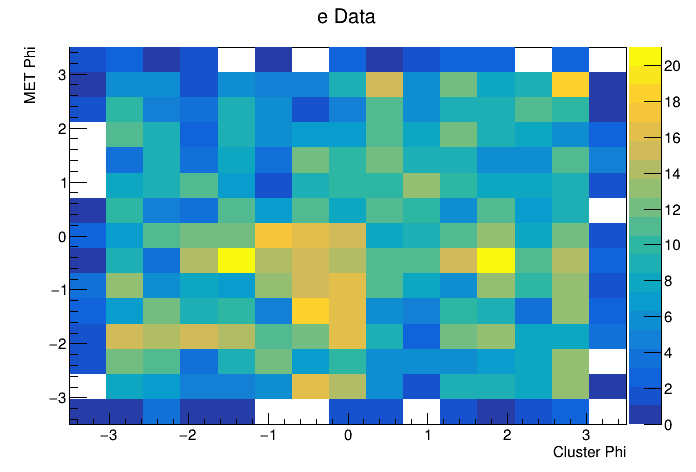

In [14]:
h2d_VR1 = ROOT.TH2D("", "e Data;Cluster Phi;MET Phi", 15, -3.5, 3.5, 15, -3.5, 3.5)
for x, y in zip(cluster_phi, MET_phi):
    h2d_VR1.Fill(x,y)

c = ROOT.TCanvas()
h2d_VR1.Draw("profcolz")
c.Draw()

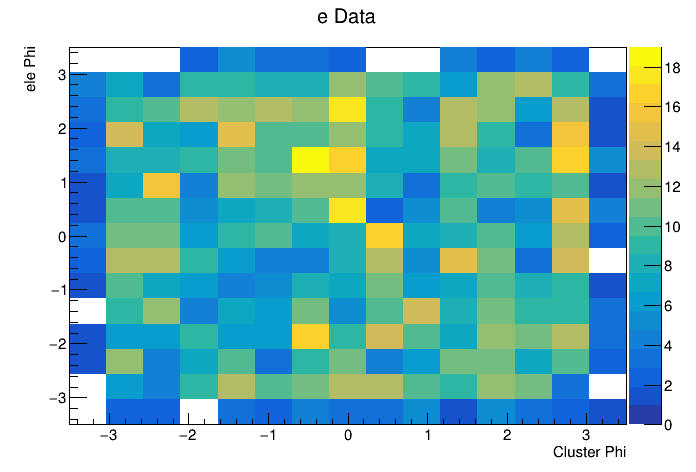

In [16]:
h2d_VR1 = ROOT.TH2D("", "e Data;Cluster Phi;ele Phi", 15, -3.5, 3.5, 15, -3.5, 3.5)
for x, y in zip(cluster_phi, e_phi):
    h2d_VR1.Fill(x,y)

c = ROOT.TCanvas()
h2d_VR1.Draw("profcolz")
c.Draw()

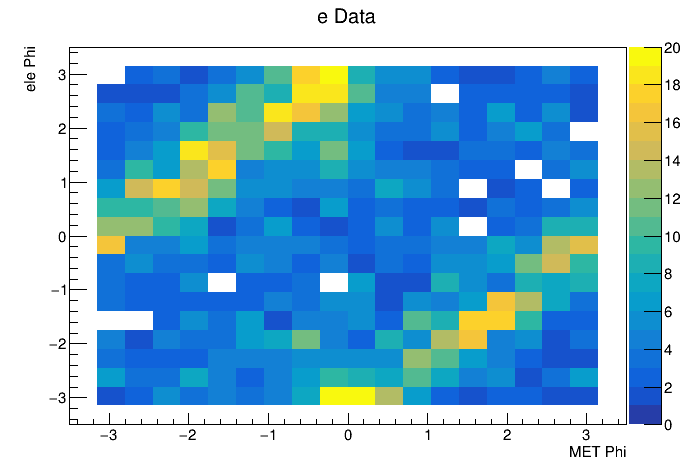

In [18]:
h2d_VR1 = ROOT.TH2D("", "e Data;MET Phi;ele Phi", 20, -3.5, 3.5, 20, -3.5, 3.5)
for x, y in zip(MET_phi, e_phi):
    h2d_VR1.Fill(x,y)

c = ROOT.TCanvas()
h2d_VR1.Draw("profcolz")
c.Draw()

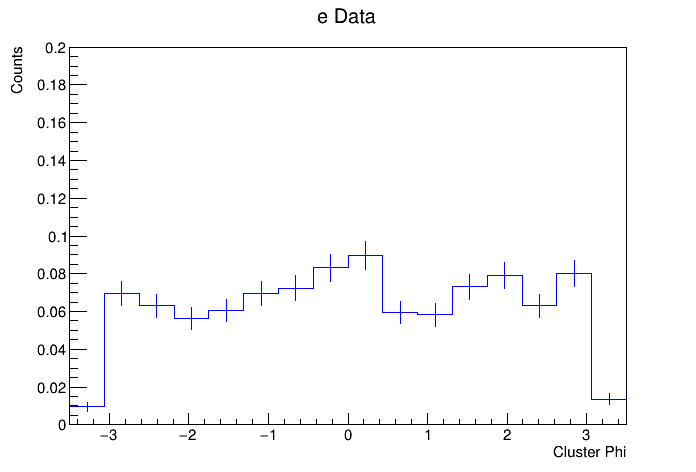

In [35]:
h2d_VR1 = ROOT.TH1D("", "e Data;Cluster Phi;Counts", 16, -3.5, 3.5)
h2d_VR2 = ROOT.TH1D("", "e Data;Cluster Phi;Counts", 16, -3.5, 3.5)
for x in cluster_phi:
    h2d_VR1.Fill(x)
    h2d_VR1.SetLineColor(ROOT.kBlue)

for x in cluster_phi_largeCluster:
    h2d_VR2.Fill(x)
    h2d_VR2.SetLineColor(ROOT.kRed)

h2d_VR1.Scale(1/h2d_VR1.GetEntries())
h2d_VR2.Scale(1/h2d_VR2.GetEntries())  
c = ROOT.TCanvas()
h2d_VR1.Draw("HIST E")
h2d_VR1.GetYaxis().SetRangeUser(0,0.2)
#h2d_VR2.Draw("HIST  E SAME")
c.Draw()

In [20]:
len(cluster_phi_largeCluster)

561

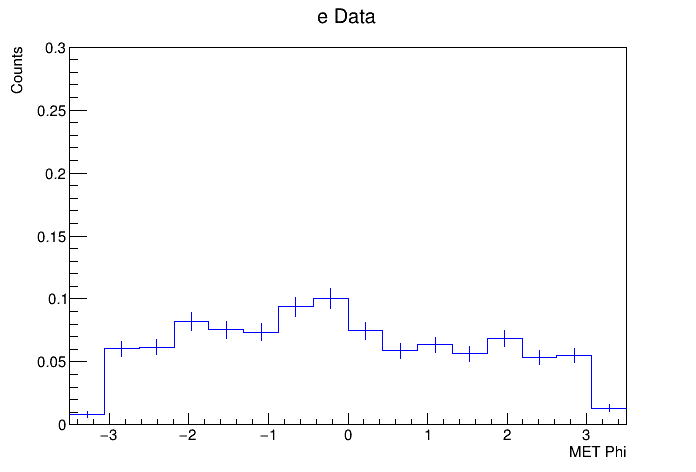

In [36]:
h2d_VR1 = ROOT.TH1D("", "e Data;MET Phi;Counts", 16, -3.5, 3.5)
h2d_VR2 = ROOT.TH1D("", "e Data;MET Phi;Counts", 16, -3.5, 3.5)
for x in MET_phi:
    h2d_VR1.Fill(x)
    h2d_VR1.SetLineColor(ROOT.kBlue)

for x in MET_phi_largeCluster:
    h2d_VR2.Fill(x)
    h2d_VR2.SetLineColor(ROOT.kRed)

h2d_VR1.Scale(1/h2d_VR1.GetEntries())
h2d_VR2.Scale(1/h2d_VR2.GetEntries())  
c = ROOT.TCanvas()
h2d_VR1.Draw("HIST E")
h2d_VR1.GetYaxis().SetRangeUser(0,0.3)
#h2d_VR2.Draw("HIST SAME")
c.Draw()

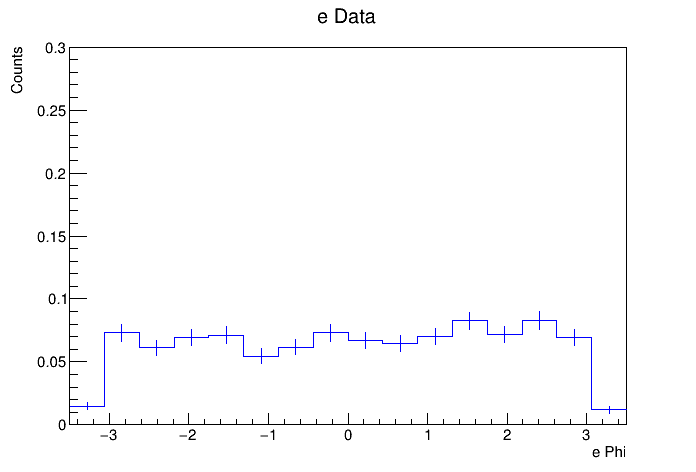

In [37]:
h2d_VR1 = ROOT.TH1D("", "e Data;e Phi;Counts", 16, -3.5, 3.5)
h2d_VR2 = ROOT.TH1D("", "e Data;e Phi;Counts", 16, -3.5, 3.5)
for x in e_phi:
    h2d_VR1.Fill(x)
    h2d_VR1.SetLineColor(ROOT.kBlue)

for x in e_phi_largeCluster:
    h2d_VR2.Fill(x)
    h2d_VR2.SetLineColor(ROOT.kRed)

h2d_VR1.Scale(1/h2d_VR1.GetEntries())
h2d_VR2.Scale(1/h2d_VR2.GetEntries())  
c = ROOT.TCanvas()
h2d_VR1.Draw("HIST E")
h2d_VR1.GetYaxis().SetRangeUser(0,0.3)
#h2d_VR2.Draw("HIST SAME")
c.Draw()

### for signal

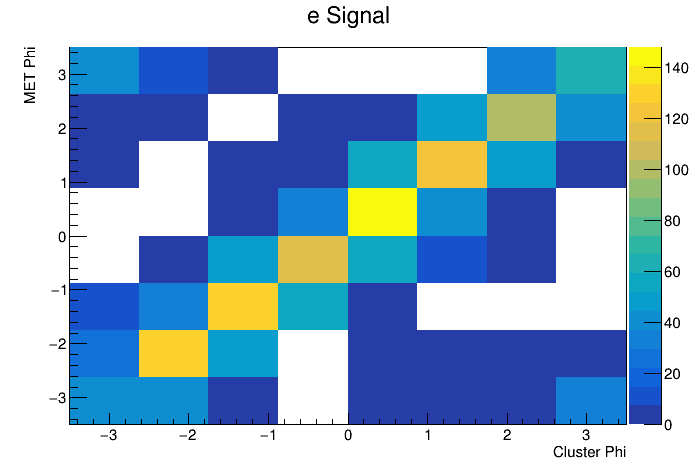

In [26]:
h2d_VR1 = ROOT.TH2D("", "e Signal;Cluster Phi;MET Phi", 8, -3.5, 3.5, 8, -3.5, 3.5)
for x, y in zip(cluster_phi_signal, MET_phi_signal):
    h2d_VR1.Fill(x,y)

c = ROOT.TCanvas()
h2d_VR1.Draw("profcolz")
c.Draw()

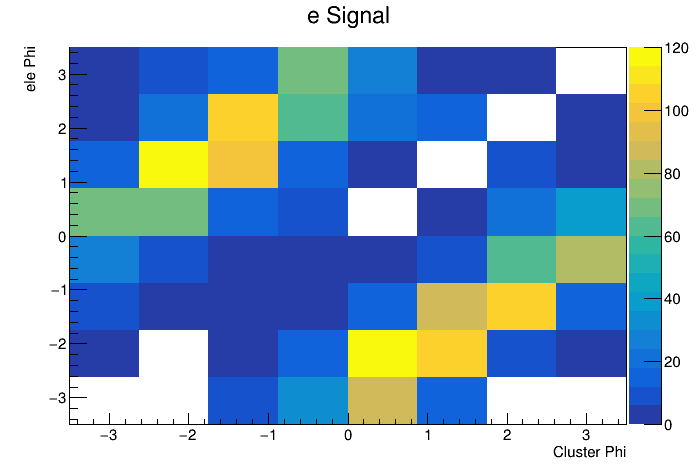

In [27]:
h2d_VR1 = ROOT.TH2D("", "e Signal;Cluster Phi;ele Phi", 8, -3.5, 3.5, 8, -3.5, 3.5)
for x, y in zip(cluster_phi_signal, e_phi_signal):
    h2d_VR1.Fill(x,y)

c = ROOT.TCanvas()
h2d_VR1.Draw("profcolz")
c.Draw()

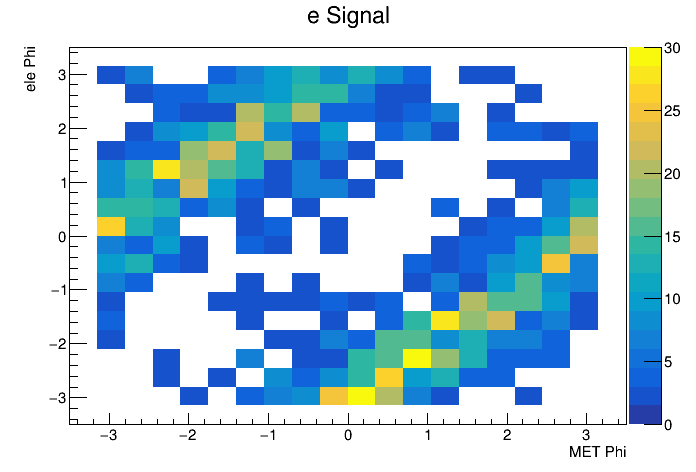

In [28]:
h2d_VR1 = ROOT.TH2D("", "e Signal;MET Phi;ele Phi", 20, -3.5, 3.5, 20, -3.5, 3.5)
for x, y in zip(MET_phi_signal, e_phi_signal):
    h2d_VR1.Fill(x,y)

c = ROOT.TCanvas()
h2d_VR1.Draw("profcolz")
c.Draw()

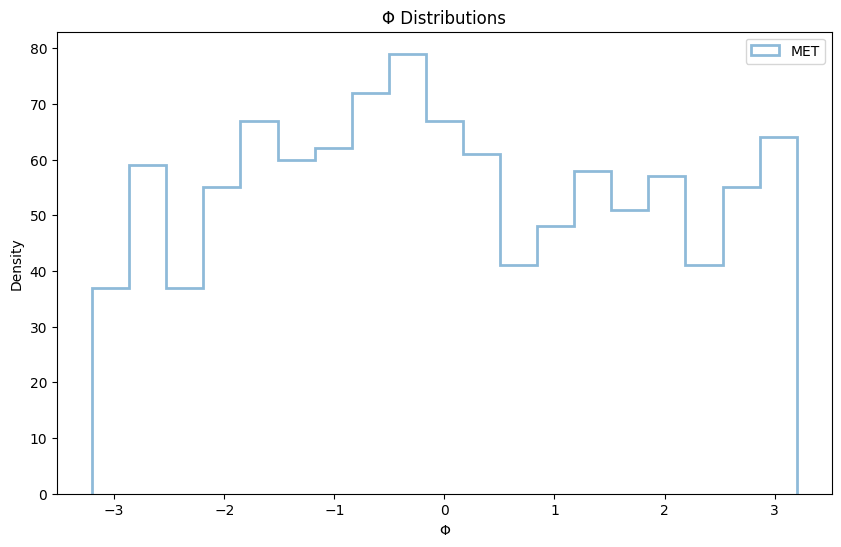

In [115]:
plt.figure(figsize=(10, 6))
#plt.hist(e_phi, bins=np.linspace(-3.2, 3.2, 20), alpha=0.5, label='Electron', histtype='step', linewidth=2)
#plt.hist(cluster_phi, bins=np.linspace(-3.2, 3.2, 20), alpha=0.5, label='Cluster', histtype='step', linewidth=2)
plt.hist(MET_phi, bins=np.linspace(-3.2, 3.2, 20), alpha=0.5, label='MET', histtype='step', linewidth=2)
plt.xlabel('Φ')
plt.ylabel('Density')
plt.title('Φ Distributions')
plt.legend()
#plt.yscale('log')
#plt.ylim(0, 1)
plt.show()

In [46]:
#apply cuts on data

#adjust the ID for electron, muon, and tau to not unblind

#i.e. checking the distribution from tau ID loose to tight, compare large dPhiMET with small dPhiMET

#check for DNN, cluster size, and dPhi(cluster, lepton/tau)

e_VR = data_events_e[return_preselections_mask(data_events_e, flavor='e', invertdPhi=True)]
e_SR = data_events_e[return_preselections_mask(data_events_e, flavor='e', invertdPhi=False)]

# mu_VR = data_events_mu[return_preselections_mask(data_events_mu, flavor='mu', invertdPhi=True)]
# mu_SR = data_events_mu[return_preselections_mask(data_events_mu, flavor='mu', invertdPhi=False)]

# tau_VR = data_events_tau[return_preselections_mask(data_events_tau, flavor='tau', invertdPhi=True)]
# tau_SR = data_events_tau[return_preselections_mask(data_events_tau, flavor='tau', invertdPhi=False)]

In [47]:
# e_VR_DNN = e_VR.cscRechitClusterDNN_bkgMC_plusBeamHalo.compute()
# e_SR_DNN = e_SR.cscRechitClusterDNN_bkgMC_plusBeamHalo.compute()

# e_VR_clusterSize = e_VR.cscRechitClusterSize.compute()
# e_SR_clusterSize = e_SR.cscRechitClusterSize.compute()

e_VR_dPhi = e_VR.cscRechitClusterPromptEleDeltaPhi.compute()
e_SR_dPhi = e_SR.cscRechitClusterPromptEleDeltaPhi.compute()

OSError: File did not open properly: [ERROR] Server responded with an error: [3014] Unable to open file  /store/group/lpclonglived/amalbert/HNL_Tau_Search/2024_Data_e_analyzer_update_042926/Muon0-Run2024B-PromptReco-v1/normalized/Muon0-Run2024B-PromptReco-v1_goodLumi.root; Network is unreachable


In [ ]:
mu_VR_DNN = mu_VR.cscRechitClusterDNN_bkgMC_plusBeamHalo.compute()
mu_SR_DNN = mu_SR.cscRechitClusterDNN_bkgMC_plusBeamHalo.compute()

mu_VR_clusterSize = mu_VR.cscRechitClusterSize.compute()
mu_SR_clusterSize = mu_SR.cscRechitClusterSize.compute()

mu_VR_dPhi = mu_VR.cscRechitClusterPromptEleDeltaPhi.compute()
mu_SR_dPhi = mu_SR.cscRechitClusterPromptEleDeltaPhi.compute()

In [ ]:
tau_VR_DNN = tau_VR.cscRechitClusterDNN_bkgMC_plusBeamHalo.compute()
tau_SR_DNN = tau_SR.cscRechitClusterDNN_bkgMC_plusBeamHalo.compute()

tau_VR_clusterSize = tau_VR.cscRechitClusterSize.compute()
tau_SR_clusterSize = tau_SR.cscRechitClusterSize.compute()

tau_VR_dPhi = tau_VR.cscRechitClusterPromptEleDeltaPhi.compute()
tau_SR_dPhi = tau_SR.cscRechitClusterPromptEleDeltaPhi.compute()

### e plots

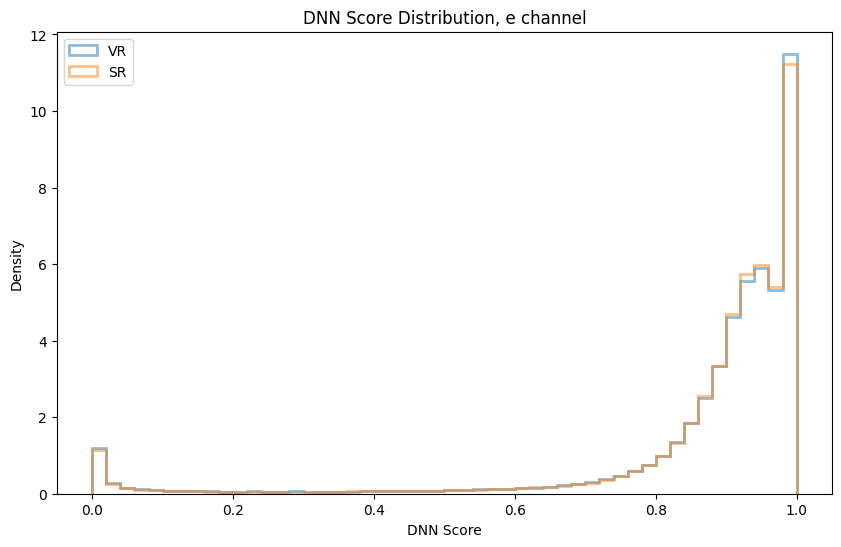

In [56]:
plt.figure(figsize=(10, 6))
plt.hist(e_VR_DNN, bins=50, alpha=0.5, label='VR', density=True, histtype='step', linewidth=2)
plt.hist(e_SR_DNN, bins=50, alpha=0.5, label='SR', density=True, histtype='step', linewidth=2)
plt.xlabel('DNN Score')
plt.ylabel('Density')
plt.title('DNN Score Distribution, e channel')
plt.legend()
plt.show()

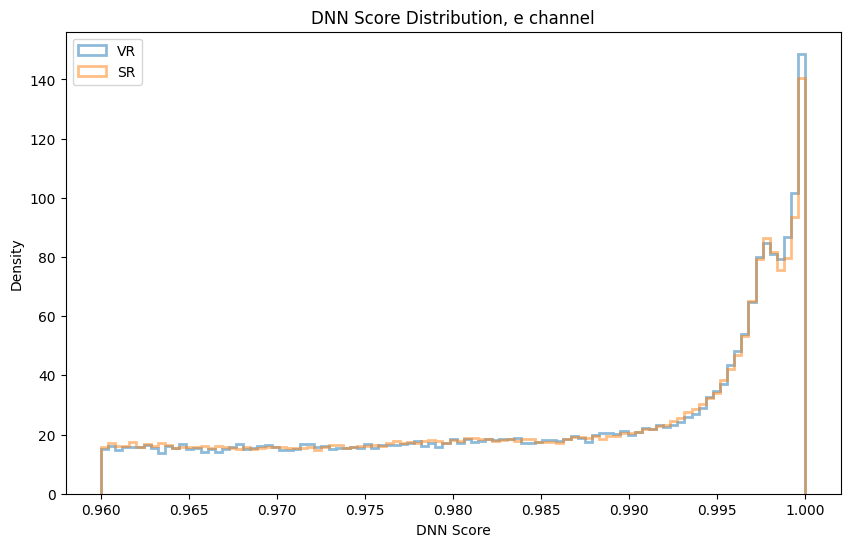

In [57]:
plt.figure(figsize=(10, 6))
plt.hist(e_VR_DNN, bins=np.linspace(0.96,1,100), alpha=0.5, label='VR', density=True, histtype='step', linewidth=2)
plt.hist(e_SR_DNN, bins=np.linspace(0.96,1,100), alpha=0.5, label='SR', density=True, histtype='step', linewidth=2)
plt.xlabel('DNN Score')
plt.ylabel('Density')
plt.title('DNN Score Distribution, e channel')
plt.legend()
plt.show()

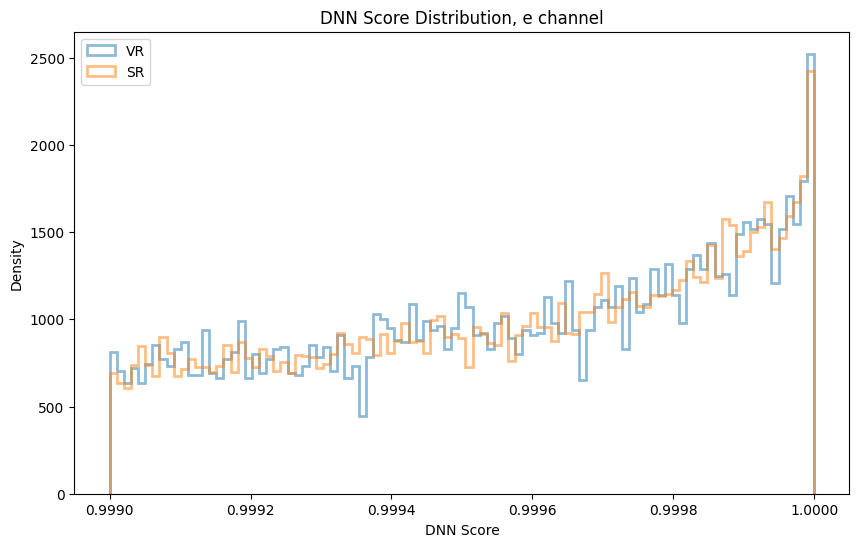

In [58]:
plt.figure(figsize=(10, 6))
plt.hist(e_VR_DNN, bins=np.linspace(0.999,1,100), alpha=0.5, label='VR', density=True, histtype='step', linewidth=2)
plt.hist(e_SR_DNN, bins=np.linspace(0.999,1,100), alpha=0.5, label='SR', density=True, histtype='step', linewidth=2)
plt.xlabel('DNN Score')
plt.ylabel('Density')
plt.title('DNN Score Distribution, e channel')
plt.legend()
plt.show()

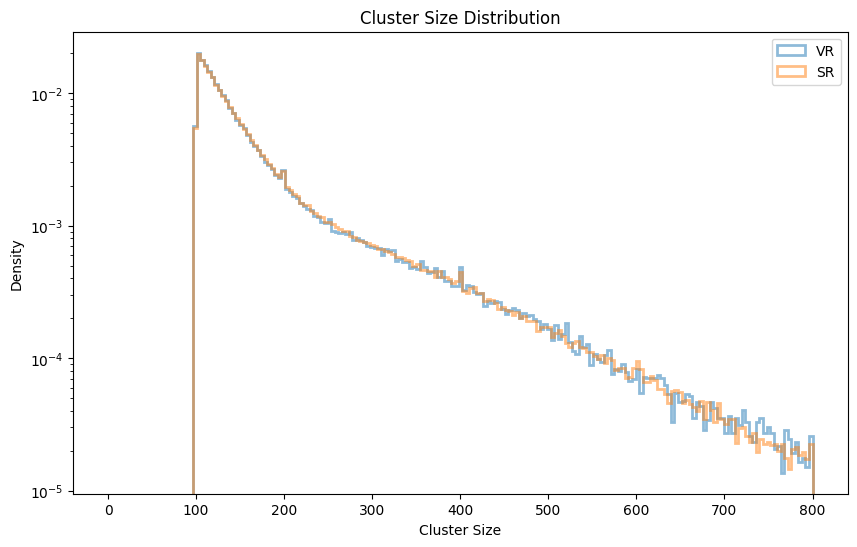

In [59]:
plt.figure(figsize=(10, 6))
plt.hist(e_VR_clusterSize, bins=np.linspace(0, 800, 200), alpha=0.5, label='VR', density=True, histtype='step', linewidth=2)
plt.hist(e_SR_clusterSize, bins=np.linspace(0, 800, 200), alpha=0.5, label='SR', density=True, histtype='step', linewidth=2)
plt.xlabel('Cluster Size')
plt.ylabel('Density')
plt.title('Cluster Size Distribution')
plt.yscale('log')
plt.legend()
plt.show()

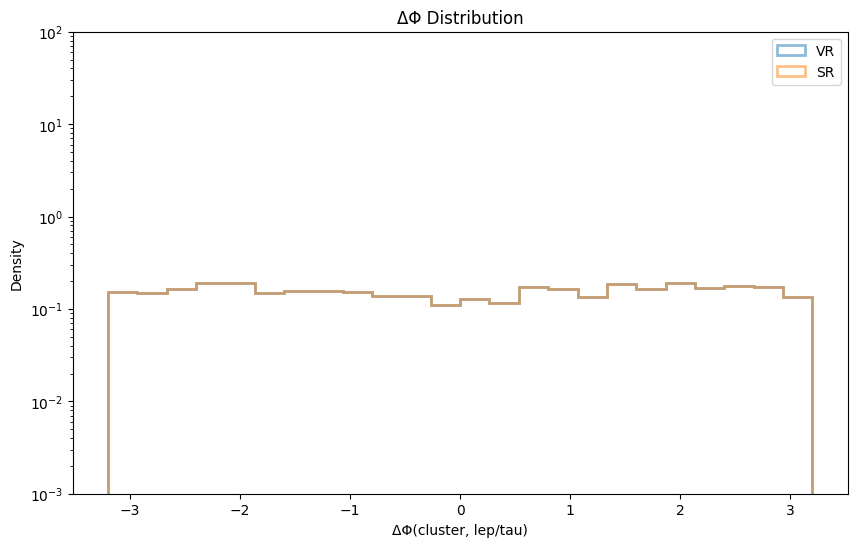

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(e_VR_dPhi, bins=np.linspace(-3.2, 3.2, 25), alpha=0.5, density=True, histtype='step', linewidth=2)
#plt.hist(e_SR_dPhi, bins=np.linspace(-3.2, 3.2, 25), alpha=0.5, label='SR', density=True, histtype='step', linewidth=2)
plt.xlabel('ΔΦ(cluster, lep/tau)')
plt.ylabel('Density')
plt.title('ΔΦ Distribution')
plt.legend()
plt.yscale('log')
plt.ylim(10e-4, 10e1)
plt.show()

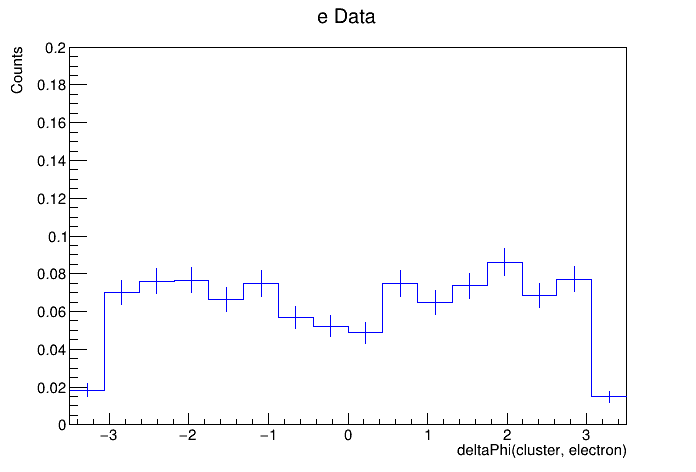

In [42]:
h2d_VR1 = ROOT.TH1D("", "e Data;deltaPhi(cluster, electron);Counts", 16, -3.5, 3.5)
#h2d_VR2 = ROOT.TH1D("", "e Data;e Phi;Counts", 16, -3.5, 3.5)
for x in e_VR_dPhi:
    #print(x)
    h2d_VR1.Fill(x[0])
h2d_VR1.SetLineColor(ROOT.kBlue)



h2d_VR1.Scale(1/h2d_VR1.GetEntries())
h2d_VR2.Scale(1/h2d_VR2.GetEntries())  
c = ROOT.TCanvas()
h2d_VR1.Draw("HIST E")
h2d_VR1.GetYaxis().SetRangeUser(0,0.2)
#h2d_VR2.Draw("HIST SAME")
c.Draw()

In [25]:
data_events_e.fields

['runNum',
 'MC_condition',
 'lumiSec',
 'evtNum',
 'mH',
 'mX',
 'ctau',
 'jetVeto',
 'HLT_CSCCSC',
 'HLT_CSCDT',
 'HLT_CscCluster100_PNetTauhPFJet10_Loose',
 'HLT_CscCluster100_Ele5',
 'HLT_CscCluster100_Mu5',
 'HLT_CscCluster50_Photon30Unseeded',
 'HLT_CscCluster50_Photon20Unseeded',
 'HLT_PFMET120_PFMHT120_IDTight',
 'HLT_Ele30_WPTight_Gsf',
 'HLT_IsoMu24',
 'L1_SingleMuShower_Nominal',
 'L1_SingleMuShower_Tight',
 'npv',
 'npu',
 'weight',
 'pileupWeight',
 'pileupWeightUp',
 'pileupWeightDown',
 'Flag_eeBadScFilter',
 'Flag_BadPFMuonFilter',
 'Flag_hfNoisyHitsFilter',
 'Flag_BadPFMuonDzFilter',
 'Flag_globalSuperTightHalo2016Filter',
 'Flag_EcalDeadCellTriggerPrimitiveFilter',
 'Flag_goodVertices',
 'Flag_all',
 'Flag_ecalBadCalibFilter',
 'LHEScaleWeight',
 'MetTriggerEffDown',
 'MetTriggerEffUp',
 'MetTriggerEff',
 'rho',
 'met',
 'metPhi',
 'Puppimet',
 'PuppimetPhi',
 'PuppimetJESUp',
 'PuppimetPhiJESUp',
 'PuppimetJESDown',
 'PuppimetPhiJESDown',
 'metJESUp',
 'metJESDown',
